# Dynamic Time Warping as Front Propagation

We remove band constraints and visualize cumulative-cost front growth.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

n, m = 100, 110
t1 = np.linspace(0, 1, n)
t2 = np.linspace(0, 1, m)
x = np.sin(2*np.pi*3*t1) + 0.25*np.sin(2*np.pi*9*t1)
y = np.sin(2*np.pi*3*(t2**1.2)) + 0.25*np.sin(2*np.pi*9*(t2**1.2))
C = (x[:, None] - y[None, :])**2

D = np.full((n+1, m+1), np.inf)
D[0, 0] = 0.0
fronts = []
for i in range(1, n+1):
    for j in range(1, m+1):
        D[i, j] = C[i-1, j-1] + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    if i in [10, 25, 50, 75, 100]:
        fronts.append(D[1:,1:].copy())

i, j = n, m
path = []
while i > 0 and j > 0:
    path.append((i-1, j-1))
    k = np.argmin([D[i-1,j], D[i,j-1], D[i-1,j-1]])
    if k == 0:
        i -= 1
    elif k == 1:
        j -= 1
    else:
        i -= 1; j -= 1
path = np.array(path[::-1])


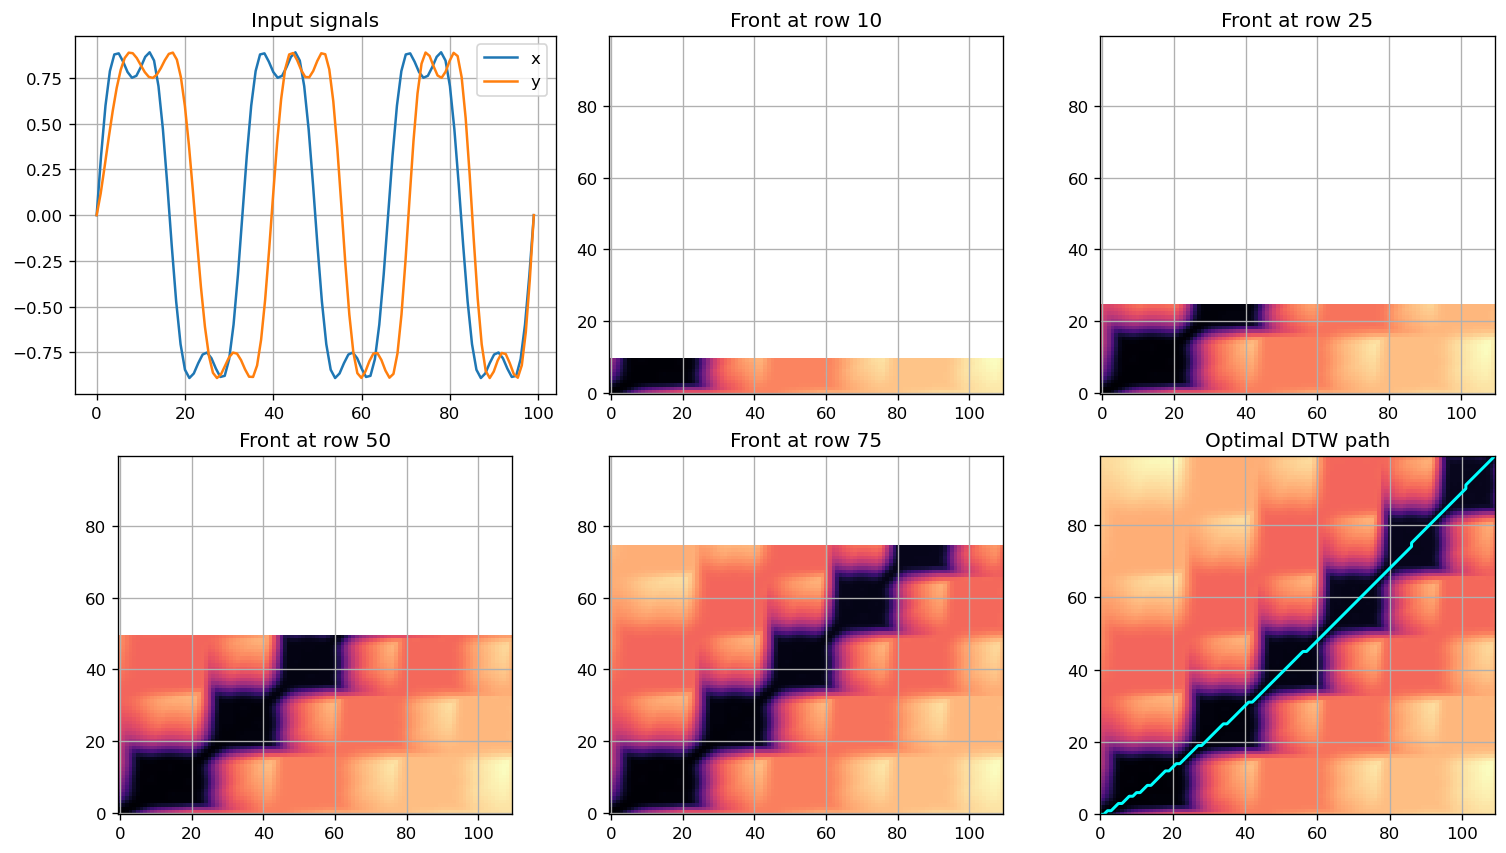

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(12.8, 7.0), constrained_layout=True)
axes[0,0].plot(x, label='x'); axes[0,0].plot(np.linspace(0, len(x)-1, len(y)), y, label='y'); axes[0,0].legend()
axes[0,0].set_title("Input signals")
for ax, F, k in zip(axes.ravel()[1:6], fronts, [10,25,50,75,100]):
    im = ax.imshow(np.log1p(F), origin='lower', cmap='magma')
    ax.set_title(f"Front at row {k}")
axes[1,2].plot(path[:,1], path[:,0], color='cyan', lw=1.8)
axes[1,2].set_xlim(0,m-1); axes[1,2].set_ylim(0,n-1)
axes[1,2].set_title("Optimal DTW path")
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
